# Trigonometric Functions — Lecture 11
## Maximum and Minimum Values (Range) of Trigonometric Expressions

**Source:** [Trigonometric Functions 11 | Maximum and Minimum Value of Trigonometric Functions](https://www.youtube.com/watch?v=4SDZtD4EVXI), Physics Wallah (Class 11 / JEE), about 50 min

**Prerequisite:** the ranges of the six basic functions (Lecture 3). *"If you don't know these, revisit that lecture first."*

### What this lecture covers
| Type | Idea | Example |
|---|---|---|
| **Type 1** | **Step by step:** start from a piece whose range you know and transform it one step at a time | $\sin^2 x + 2$, $\dfrac{2}{\sin x + 3}$, $\dfrac{2\sec^2 x + 3}{\sec^2 x + 5}$ |
| **Type 2** | **Reduce to a single varying term** (formula or completing the square) | $\sin x\cos x$, $\sin^2 x + \sin x + 1$ |
| **Type 3** | $a\sin\theta + b\cos\theta \in \left[-\sqrt{a^2+b^2},\ \sqrt{a^2+b^2}\right]$ | $2\sin\theta + 3\cos\theta$ |
| **Type 4** | Completing a perfect square with $\tan$/$\cot$ | $a^2\tan^2\theta + b^2\cot^2\theta$, $a^2\sec^2\theta + b^2\csc^2\theta$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Polygon

# Same look as the earlier lectures
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
rng = np.random.default_rng(11)
X = np.linspace(-2*np.pi, 2*np.pi, 400_001)          # dense grid for numerical ranges

def numeric_range(y):
    y = y[np.isfinite(y)]
    return y.min(), y.max()

def show_range(name, y, claimed):
    lo, hi = numeric_range(y)
    hi_s = "unbounded (→ ∞)" if hi > 1e6 else f"{hi:9.5f}"
    print(f"{name:<34} numerical min ≈ {lo:9.5f}, max ≈ {hi_s:>15}    claimed: {claimed}")

def interval_chain(ax, steps, title, xlim):
    # Draw a sequence of intervals, one per row: (label, lo, hi, lo_closed, hi_closed)
    for i, (lab, lo, hi, lc, hc) in enumerate(steps):
        y = len(steps) - 1 - i
        hi_draw = min(hi, xlim[1])
        ax.plot([lo, hi_draw], [y, y], color=BLUE if i < len(steps) - 1 else ORANGE, lw=6, solid_capstyle="butt")
        ax.plot(lo, y, "o", ms=9, mfc=INK if lc else "white", mec=INK, zorder=5)
        if np.isfinite(hi):
            ax.plot(hi, y, "o", ms=9, mfc=INK if hc else "white", mec=INK, zorder=5)
        else:
            ax.annotate("", xy=(xlim[1], y), xytext=(xlim[1] - 0.3, y), arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2))
        ax.text(xlim[0] - 0.05*(xlim[1] - xlim[0]), y, lab, ha="right", va="center", fontsize=10)
    ax.set_yticks([]); ax.set_xlim(*xlim); ax.set_ylim(-0.7, len(steps) - 0.3)
    ax.spines["left"].set_visible(False); ax.set_title(title, fontsize=11)
print("ready")

ready


---
## 0. Recap: Ranges of the Six Functions

| Function | Range |
|---|---|
| $\sin x$, $\cos x$ | $[-1, 1]$ |
| $\tan x$, $\cot x$ | $\mathbb{R}$ |
| $\sec x$, $\csc x$ | $(-\infty, -1] \cup [1, \infty)$, never strictly between $-1$ and $1$ |

Two consequences used throughout this lecture:
- $\sin^2 x, \cos^2 x \in [0, 1]$
- $\sec^2 x, \csc^2 x \in [1, \infty)$, and $\tan^2 x, \cot^2 x \in [0, \infty)$

---
## 1. Type 1: Step by Step

> **Find the part of the expression whose range you already know, then build the full expression one operation at a time**, tracking the interval through each step.

Rules for each step, applied to an interval $[p, q]$:
- **Add** $c$: gives $[p + c, q + c]$
- **Multiply** by $k > 0$: gives $[kp, kq]$. If $k < 0$, the interval **flips**.
- **Square**: watch out for $0$. From $[-1, 1]$, squaring gives $[0, 1]$, not $[1, 1]$.
- **Reciprocal** (with $p, q$ both $> 0$): gives $[1/q, 1/p]$. *"The reciprocal of the small is big, the reciprocal of the big is small."*

### Example 1: $y = \sin^2 x + 2$
$$\sin x \in [-1, 1] \;\to\; \sin^2 x \in [0, 1] \;\to\; \sin^2 x + 2 \in \boxed{[2, 3]}$$

### Example 2: $y = \dfrac{2}{\sin x + 3}$
$$\sin x \in [-1, 1] \;\to\; \sin x + 3 \in [2, 4] \;\to\; \frac{1}{\sin x + 3} \in \left[\tfrac14, \tfrac12\right] \;\to\; \frac{2}{\sin x + 3} \in \boxed{\left[\tfrac12, 1\right]}$$

### Example 3: $y = \dfrac{2\sec^2 x + 3}{\sec^2 x + 5}$
Here $\sec^2 x$ appears **twice**, and two varying terms are hard to track together. Rewrite so it appears **once**:
$$y = \frac{2(\sec^2 x + 5) - 7}{\sec^2 x + 5} = 2 - \frac{7}{\sec^2 x + 5}$$
The two forms are equal, but only the second is easy to handle.

Now step by step:
$$\sec^2 x \in [1, \infty) \;\to\; \sec^2 x + 5 \in [6, \infty) \;\to\; \frac{1}{\sec^2 x + 5} \in \left(0, \tfrac16\right] \;\to\; -\frac{7}{\sec^2 x + 5} \in \left[-\tfrac76, 0\right) \;\to\; y \in \boxed{\left[\tfrac56,\ 2\right)}$$

(The lecture writes "$\frac56$ to $2$". Note that $2$ is **never reached**: it would need $\sec^2 x = \infty$. Adding $5$ to infinity is still infinity, *"like adding five drops of water to the sea."*)

sin²x + 2                          numerical min ≈   2.00000, max ≈         3.00000    claimed: [2, 3]
2/(sin x + 3)                      numerical min ≈   0.50000, max ≈         1.00000    claimed: [1/2, 1]
(2sec²x + 3)/(sec²x + 5)           numerical min ≈   0.83333, max ≈         2.00000    claimed: [5/6, 2)   (2 approached, never reached)


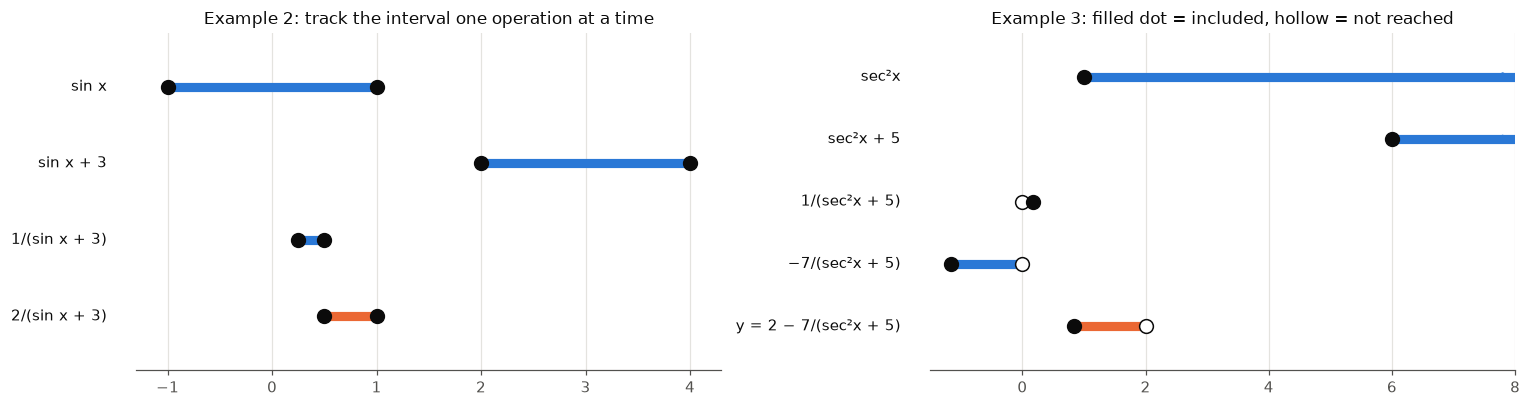

In [2]:
with np.errstate(divide="ignore", invalid="ignore"):
    sec2 = 1/np.cos(X)**2
    show_range("sin²x + 2", np.sin(X)**2 + 2, "[2, 3]")
    show_range("2/(sin x + 3)", 2/(np.sin(X) + 3), "[1/2, 1]")
    show_range("(2sec²x + 3)/(sec²x + 5)", (2*sec2 + 3)/(sec2 + 5), "[5/6, 2)   (2 approached, never reached)")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
interval_chain(axes[0], [
    ("sin x", -1, 1, True, True),
    ("sin x + 3", 2, 4, True, True),
    ("1/(sin x + 3)", 0.25, 0.5, True, True),
    ("2/(sin x + 3)", 0.5, 1, True, True)],
    "Example 2: track the interval one operation at a time", (-1.3, 4.3))
interval_chain(axes[1], [
    ("sec²x", 1, np.inf, True, False),
    ("sec²x + 5", 6, np.inf, True, False),
    ("1/(sec²x + 5)", 0, 1/6, False, True),
    ("−7/(sec²x + 5)", -7/6, 0, True, False),
    ("y = 2 − 7/(sec²x + 5)", 5/6, 2, True, False)],
    "Example 3: filled dot = included, hollow = not reached", (-1.5, 8))
plt.tight_layout(); plt.show()

---
## 2. Type 2: Reduce to a Single Varying Term

> If **two or more** terms vary together (e.g. $\sin x$ and $\cos x$, or $\sin^2 x$ and $\sin x$), the human brain can't track them easily. **Convert to one varying term** using a formula or by completing the square, then use Type 1.

This idea works far beyond trigonometry. It is a general tool for finding ranges.

### Example 4: $y = \sin x\cos x$
Multiply and divide by 2:
$$y = \tfrac12(2\sin x\cos x) = \tfrac12\sin 2x$$
Since $\sin(\text{anything}) \in [-1, 1]$, we get $y \in \boxed{\left[-\tfrac12, \tfrac12\right]}$.

### Example 5: $y = \sin^2 x + \sin x + 1$
**Complete the square.** This is the go-to move for a quadratic:
$$\sin^2 x + 2\cdot\sin x\cdot\tfrac12 + \tfrac14 + \tfrac34 = \left(\sin x + \tfrac12\right)^2 + \tfrac34$$
Now only one term varies.

- **Minimum:** a square is $\ge 0$, so $y \ge \frac34$. Equality at $\sin x = -\frac12$, which is allowed.
- **Maximum:** make the square as big as possible. The largest $\sin x$ can be is $1$, giving $\left(\frac32\right)^2 + \frac34 = \frac94 + \frac34 = 3$.

$$y \in \boxed{\left[\tfrac34,\ 3\right]}$$

**Careful:** the minimum needs the inside of the square to reach $0$, i.e. $\sin x = -\frac12$, which lies inside $[-1, 1]$. If it didn't, the minimum would be at an endpoint. (See the homework trap below.)

sin x · cos x                      numerical min ≈  -0.50000, max ≈         0.50000    claimed: [−1/2, 1/2]
sin²x + sin x + 1                  numerical min ≈   0.75000, max ≈         3.00000    claimed: [3/4, 3]


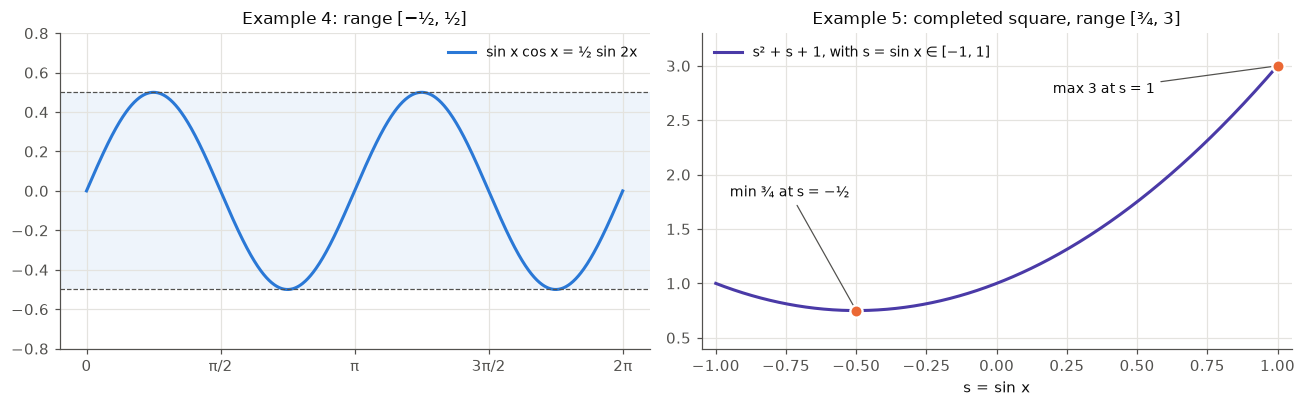

In [3]:
show_range("sin x · cos x", np.sin(X)*np.cos(X), "[−1/2, 1/2]")
show_range("sin²x + sin x + 1", np.sin(X)**2 + np.sin(X) + 1, "[3/4, 3]")

s = np.linspace(-1, 1, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
x = np.linspace(0, 2*np.pi, 800)
ax.plot(x, np.sin(x)*np.cos(x), color=BLUE, lw=2, label="sin x cos x = ½ sin 2x")
ax.axhspan(-0.5, 0.5, color=BLUE, alpha=0.08, lw=0)
for v in (-0.5, 0.5): ax.axhline(v, color=INK2, lw=0.8, ls="--")
ax.set_xticks(np.arange(0, 2.01, 0.5)*np.pi, ["0", "π/2", "π", "3π/2", "2π"]); ax.set_ylim(-0.8, 0.8)
ax.legend(frameon=False, fontsize=9, loc="upper right"); ax.set_title("Example 4: range [−½, ½]", fontsize=11)

ax = axes[1]
ax.plot(s, s**2 + s + 1, color=VIOLET, lw=2, label="s² + s + 1, with s = sin x ∈ [−1, 1]")
ax.plot(-0.5, 0.75, "o", color=ORANGE, ms=8, mec="white", mew=1.5, zorder=5)
ax.plot(1, 3, "o", color=ORANGE, ms=8, mec="white", mew=1.5, zorder=5)
ax.annotate("min ¾ at s = −½", (-0.5, 0.75), xytext=(-0.95, 1.8), fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.annotate("max 3 at s = 1", (1, 3), xytext=(0.2, 2.75), fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.set_xlabel("s = sin x"); ax.set_xlim(-1.05, 1.05); ax.set_ylim(0.4, 3.3)
ax.legend(frameon=False, fontsize=9, loc="upper left"); ax.set_title("Example 5: completed square, range [¾, 3]", fontsize=11)
plt.tight_layout(); plt.show()

---
## 3. Type 3: $a\sin\theta + b\cos\theta$

$$\boxed{-\sqrt{a^2 + b^2} \;\le\; a\sin\theta + b\cos\theta \;\le\; \sqrt{a^2 + b^2}}$$

The **procedure** behind this result matters. It comes up again in Class 12 integration.

### Proof
Multiply and divide by $\sqrt{a^2 + b^2}$:
$$y = \sqrt{a^2 + b^2}\left(\frac{a}{\sqrt{a^2+b^2}}\sin\theta + \frac{b}{\sqrt{a^2+b^2}}\cos\theta\right)$$
Since $\left(\frac{a}{\sqrt{a^2+b^2}}\right)^2 + \left(\frac{b}{\sqrt{a^2+b^2}}\right)^2 = 1$, we can **name an angle** $\alpha$ with
$$\cos\alpha = \frac{a}{\sqrt{a^2+b^2}}, \qquad \sin\alpha = \frac{b}{\sqrt{a^2+b^2}}$$
(think of a right triangle with legs $a$ and $b$ and hypotenuse $\sqrt{a^2+b^2}$). Then
$$y = \sqrt{a^2+b^2}\,(\sin\theta\cos\alpha + \cos\theta\sin\alpha) = \sqrt{a^2+b^2}\,\sin(\theta + \alpha)$$
Since $\sin(\theta + \alpha) \in [-1, 1]$, we get $y \in \left[-\sqrt{a^2+b^2}, \sqrt{a^2+b^2}\right]$ $\blacksquare$

**Two varying terms became one:** this is Type 2's idea in action.

### Example 6: $y = 2\sin\theta + 3\cos\theta$
$\sqrt{2^2 + 3^2} = \sqrt{13}$, so $y \in \boxed{\left[-\sqrt{13},\ \sqrt{13}\right]}$.

(Classic variant: $3\sin\theta + 4\cos\theta \in [-5, 5]$.)

> **Homework from the lecture:** find the range of an expression that doesn't look like $a\sin\theta + b\cos\theta$ at first (it involves compound angles). The hint is to **reshape it into that form**. The exact expression is garbled in the captions. A stand-in with the same idea is
> $$y = 3\sin x + 4\cos\left(x + \tfrac{\pi}{3}\right)$$
> and its answer is in the cell below.

In [4]:
for a, b in [(2, 3), (3, 4), (5, 12)]:
    show_range(f"{a} sinθ + {b} cosθ", a*np.sin(X) + b*np.cos(X), f"[−{np.sqrt(a*a + b*b):.5f}, {np.sqrt(a*a + b*b):.5f}]  (√{a*a + b*b})")

# Stand-in homework: 3 sin x + 4 cos(x + π/3) = 3 sin x + 2 cos x − 2√3 sin x = (3 − 2√3) sin x + 2 cos x
A, B = 3 - 2*np.sqrt(3), 2
show_range("3 sin x + 4 cos(x + π/3)", 3*np.sin(X) + 4*np.cos(X + np.pi/3), f"±√(A² + B²) = ±{np.hypot(A, B):.5f}  (= ±√(25 − 12√3))")

2 sinθ + 3 cosθ                    numerical min ≈  -3.60555, max ≈         3.60555    claimed: [−3.60555, 3.60555]  (√13)
3 sinθ + 4 cosθ                    numerical min ≈  -5.00000, max ≈         5.00000    claimed: [−5.00000, 5.00000]  (√25)
5 sinθ + 12 cosθ                   numerical min ≈ -13.00000, max ≈        13.00000    claimed: [−13.00000, 13.00000]  (√169)
3 sin x + 4 cos(x + π/3)           numerical min ≈  -2.05314, max ≈         2.05314    claimed: ±√(A² + B²) = ±2.05314  (= ±√(25 − 12√3))


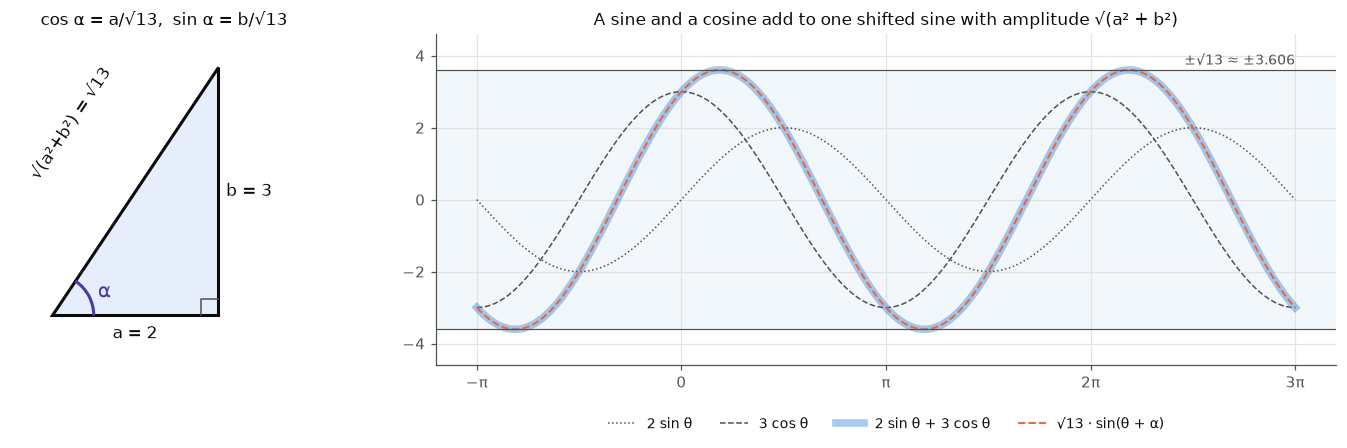

In [5]:
a, b = 2, 3
R = np.hypot(a, b); alpha = np.arctan2(b, a)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 2]})

ax = axes[0]; ax.set_aspect("equal"); ax.axis("off")
ax.add_patch(Polygon([(0, 0), (a, 0), (a, b)], closed=True, fc=BLUE + "1f", ec=INK, lw=2))
ax.plot([a - 0.2, a - 0.2, a], [0, 0.2, 0.2], color=INK2, lw=1)
ax.add_patch(Arc((0, 0), 1.0, 1.0, theta1=0, theta2=np.rad2deg(alpha), color=VIOLET, lw=2))
ax.text(0.55, 0.22, "α", color=VIOLET, fontsize=13)
ax.text(a/2, -0.12, f"a = {a}", ha="center", va="top", fontsize=11)
ax.text(a + 0.1, b/2, f"b = {b}", va="center", fontsize=11)
ax.text(a/2 - 0.25, b/2 + 0.15, f"√(a²+b²) = √13", ha="right", fontsize=11, rotation=np.rad2deg(alpha))
ax.set_xlim(-0.5, 3.2); ax.set_ylim(-0.6, 3.4)
ax.set_title("cos α = a/√13,  sin α = b/√13", fontsize=11)

ax = axes[1]
t = np.linspace(-np.pi, 3*np.pi, 1500)
ax.plot(t, a*np.sin(t), color=INK2, lw=1, ls=":", label="2 sin θ")
ax.plot(t, b*np.cos(t), color=INK2, lw=1, ls="--", label="3 cos θ")
ax.plot(t, a*np.sin(t) + b*np.cos(t), color=BLUE, lw=5, alpha=0.4, label="2 sin θ + 3 cos θ")
ax.plot(t, R*np.sin(t + alpha), color=ORANGE, lw=1.3, ls="--", label="√13 · sin(θ + α)")
ax.axhspan(-R, R, color=BLUE, alpha=0.06, lw=0)
for v in (-R, R): ax.axhline(v, color=INK2, lw=0.8)
ax.text(3*np.pi, R + 0.15, "±√13 ≈ ±3.606", ha="right", fontsize=9, color=INK2)
ax.set_xticks(np.arange(-1, 3.01, 1)*np.pi, ["−π", "0", "π", "2π", "3π"]); ax.set_ylim(-4.6, 4.6)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
ax.set_title("A sine and a cosine add to one shifted sine with amplitude √(a² + b²)", fontsize=11)
plt.tight_layout(); plt.show()

---
## 4. Type 4: $a^2\tan^2\theta + b^2\cot^2\theta$ and Friends ($a, b > 0$)

### Example 7: $y = a^2\tan^2\theta + b^2\cot^2\theta$
Two varying terms, so **complete the square**. Since $\tan\theta\cot\theta = 1$, the cross term is a **constant**:
$$y = (a\tan\theta)^2 + (b\cot\theta)^2 - 2ab\tan\theta\cot\theta + 2ab = (a\tan\theta - b\cot\theta)^2 + 2ab$$
A square is $\ge 0$, so
$$\boxed{y \in [2ab, \infty)}$$
The minimum is reached when $a\tan\theta = b\cot\theta$, i.e. $\tan^2\theta = \frac{b}{a}$, which is always possible since $\tan^2$ takes every value $\ge 0$.

### Example 8: $y = a^2\sec^2\theta + b^2\csc^2\theta$
Use $\sec^2 = 1 + \tan^2$ and $\csc^2 = 1 + \cot^2$ to reduce to Example 7:
$$y = a^2 + b^2 + a^2\tan^2\theta + b^2\cot^2\theta = a^2 + b^2 + (a\tan\theta - b\cot\theta)^2 + 2ab$$
$$\boxed{y \in \left[(a + b)^2, \infty\right)}$$

> **JEE tip:** memorise both results for objective questions: $a^2\tan^2 + b^2\cot^2 \ge 2ab$ and $a^2\sec^2 + b^2\csc^2 \ge (a+b)^2$.

2²tan²θ + 3²cot²θ                  numerical min ≈  12.00000, max ≈ unbounded (→ ∞)    claimed: [2ab = 12, ∞)
2²sec²θ + 3²cosec²θ                numerical min ≈  25.00000, max ≈ unbounded (→ ∞)    claimed: [(a+b)² = 25, ∞)
1²tan²θ + 5²cot²θ                  numerical min ≈  10.00000, max ≈ unbounded (→ ∞)    claimed: [2ab = 10, ∞)
1²sec²θ + 5²cosec²θ                numerical min ≈  36.00000, max ≈ unbounded (→ ∞)    claimed: [(a+b)² = 36, ∞)


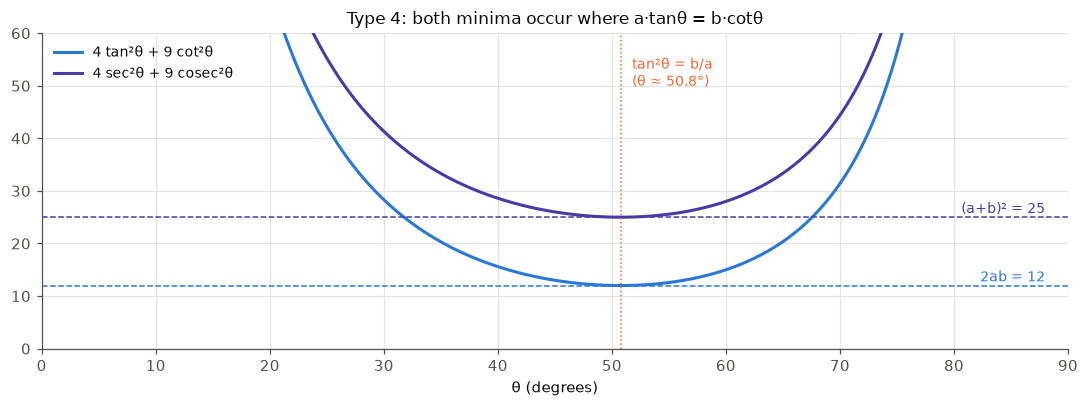

In [6]:
with np.errstate(divide="ignore", invalid="ignore"):
    for a, b in [(2, 3), (1, 5)]:
        show_range(f"{a}²tan²θ + {b}²cot²θ", a*a*np.tan(X)**2 + b*b/np.tan(X)**2, f"[2ab = {2*a*b}, ∞)")
        show_range(f"{a}²sec²θ + {b}²cosec²θ", a*a/np.cos(X)**2 + b*b/np.sin(X)**2, f"[(a+b)² = {(a + b)**2}, ∞)")

a, b = 2, 3
th = np.linspace(0.02, np.pi/2 - 0.02, 2000)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(np.rad2deg(th), a*a*np.tan(th)**2 + b*b/np.tan(th)**2, color=BLUE, lw=2, label="4 tan²θ + 9 cot²θ")
ax.plot(np.rad2deg(th), a*a/np.cos(th)**2 + b*b/np.sin(th)**2, color=VIOLET, lw=2, label="4 sec²θ + 9 cosec²θ")
ax.axhline(2*a*b, color=BLUE, lw=1, ls="--"); ax.text(88, 2*a*b + 0.8, "2ab = 12", color=BLUE, fontsize=9, ha="right")
ax.axhline((a + b)**2, color=VIOLET, lw=1, ls="--"); ax.text(88, (a + b)**2 + 0.8, "(a+b)² = 25", color=VIOLET, fontsize=9, ha="right")
tmin = np.rad2deg(np.arctan(np.sqrt(b/a)))
ax.axvline(tmin, color=ORANGE, lw=1, ls=":"); ax.text(tmin + 1, 50, f"tan²θ = b/a\n(θ ≈ {tmin:.1f}°)", color=ORANGE, fontsize=9)
ax.set_ylim(0, 60); ax.set_xlim(0, 90); ax.set_xlabel("θ (degrees)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Type 4: both minima occur where a·tanθ = b·cotθ", fontsize=11)
plt.tight_layout(); plt.show()

---
## 5. Homework from the Lecture

> **Find the range of** (as best as can be read from the captions)
> **(a)** $4\sin^2 x + 9\csc^2 x$  **(b)** $4\cos^2 x + 9\sec^2 x$
>
> The lecturer promised to name the first student who posts both correct answers in the comments.

<details>
<summary>Hint: a trap (open after attempting)</summary>

It looks like Type 4. "Square completion" would suggest a minimum of $2\sqrt{4\cdot 9} = 12$, reached when $4\sin^2 x = 9\csc^2 x$, i.e. $\sin^2 x = \frac32$. **That is impossible**, since $\sin^2 x \le 1$.

So let $t = \sin^2 x \in (0, 1]$ and study $f(t) = 4t + \frac{9}{t}$. It **decreases** all the way to $t = \frac32$, so on $(0, 1]$ the smallest value is at $t = 1$: $f(1) = 13$. As $t \to 0^+$, $f \to \infty$.

$$\text{Range} = [13, \infty) \text{ for both (a) and (b).}$$

**Lesson:** always check that the value making the square zero is actually **attainable**. Type 4 worked because $\tan^2$ can be any non-negative number. Here $\sin^2$ can't exceed $1$.
</details>

4 sin²x + 9 cosec²x                numerical min ≈  13.00000, max ≈ unbounded (→ ∞)    claimed: [13, ∞)
4 cos²x + 9 sec²x                  numerical min ≈  13.00000, max ≈ unbounded (→ ∞)    claimed: [13, ∞)


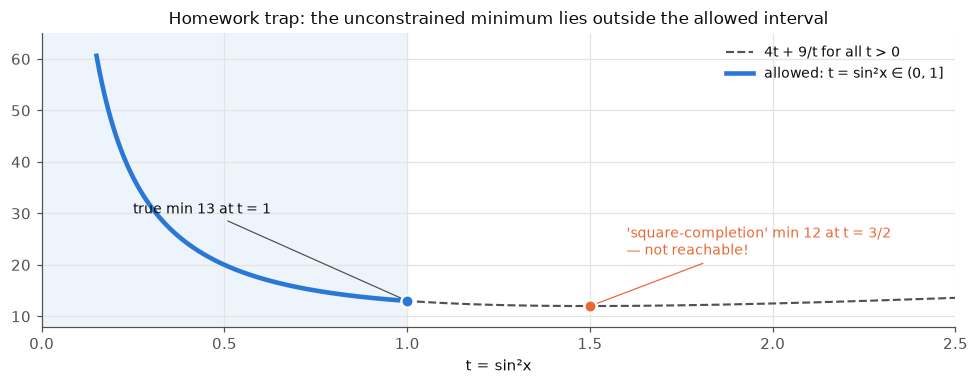

In [7]:
with np.errstate(divide="ignore", invalid="ignore"):
    show_range("4 sin²x + 9 cosec²x", 4*np.sin(X)**2 + 9/np.sin(X)**2, "[13, ∞)")
    show_range("4 cos²x + 9 sec²x", 4*np.cos(X)**2 + 9/np.cos(X)**2, "[13, ∞)")

t = np.linspace(0.15, 2.5, 600)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.axvspan(0, 1, color=BLUE, alpha=0.08, lw=0)
ax.plot(t, 4*t + 9/t, color=INK2, lw=1.4, ls="--", label="4t + 9/t for all t > 0")
tt = t[t <= 1]; ax.plot(tt, 4*tt + 9/tt, color=BLUE, lw=3, label="allowed: t = sin²x ∈ (0, 1]")
ax.plot(1.5, 12, "o", color=ORANGE, ms=8, mec="white", mew=1.5, zorder=5)
ax.annotate("'square-completion' min 12 at t = 3/2\n— not reachable!", (1.5, 12), xytext=(1.6, 22), fontsize=9,
            color=ORANGE, arrowprops=dict(arrowstyle="-", color=ORANGE, lw=0.8))
ax.plot(1, 13, "o", color=BLUE, ms=8, mec="white", mew=1.5, zorder=5)
ax.annotate("true min 13 at t = 1", (1, 13), xytext=(0.25, 30), fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.set_xlabel("t = sin²x"); ax.set_ylim(8, 65); ax.set_xlim(0, 2.5)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title("Homework trap: the unconstrained minimum lies outside the allowed interval", fontsize=11)
plt.tight_layout(); plt.show()

---
## 6. Summary

| Type | Recognise it by | Method | Result |
|---|---|---|---|
| 1 | one varying piece, built up by $+, \times, ^2, 1/\cdot$ | step-by-step interval tracking | e.g. $\frac{2}{\sin x + 3} \in [\frac12, 1]$ |
| 2 | several varying terms | formula or completing the square, so only **one** varies | $\sin x\cos x \in [-\frac12, \frac12]$; $\sin^2x + \sin x + 1 \in [\frac34, 3]$ |
| 3 | $a\sin\theta + b\cos\theta$ | divide by $\sqrt{a^2+b^2}$ to get $\sqrt{a^2+b^2}\sin(\theta + \alpha)$ | $[-\sqrt{a^2+b^2}, \sqrt{a^2+b^2}]$ |
| 4 | $a^2\tan^2 + b^2\cot^2$, or $a^2\sec^2 + b^2\csc^2$ | complete the square; the cross term $\tan\cdot\cot = 1$ is constant | $[2ab, \infty)$ and $[(a+b)^2, \infty)$ |

**Pitfalls**
- Squaring an interval that contains $0$ gives $[0, \cdot]$.
- Reciprocals flip the order. Multiplying by a negative flips the interval.
- **Endpoints:** decide whether each bound is actually reached (open or closed).
- When completing a square, check that the point making it zero is attainable (the homework trap).

### Practice
1. Range of $3 - 2\cos x$, of $\dfrac{1}{2 + \cos x}$, and of $\cos^2 x - \cos x + 1$.
2. Maximum of $5\sin\theta + 12\cos\theta + 7$.
3. Minimum of $9\tan^2\theta + 4\cot^2\theta$.
4. Range of $\sin x + \sqrt3\cos x$, and the angle at which the maximum occurs.

In [8]:
show_range("1. 3 − 2cos x", 3 - 2*np.cos(X), "[1, 5]")
show_range("1. 1/(2 + cos x)", 1/(2 + np.cos(X)), "[1/3, 1]")
show_range("1. cos²x − cos x + 1", np.cos(X)**2 - np.cos(X) + 1, "[3/4, 3]")
show_range("2. 5sinθ + 12cosθ + 7", 5*np.sin(X) + 12*np.cos(X) + 7, "max 13 + 7 = 20")
with np.errstate(divide="ignore", invalid="ignore"):
    show_range("3. 9tan²θ + 4cot²θ", 9*np.tan(X)**2 + 4/np.tan(X)**2, "min 2·3·2 = 12")
y = np.sin(X) + np.sqrt(3)*np.cos(X); i = np.argmax(y)
print(f"4. sin x + √3 cos x: range [−2, 2]; max {y[i]:.5f} at x = {np.rad2deg(X[i]) % 360:.2f}° (= 30°, since it is 2 sin(x + 60°))")

1. 3 − 2cos x                      numerical min ≈   1.00000, max ≈         5.00000    claimed: [1, 5]
1. 1/(2 + cos x)                   numerical min ≈   0.33333, max ≈         1.00000    claimed: [1/3, 1]
1. cos²x − cos x + 1               numerical min ≈   0.75000, max ≈         3.00000    claimed: [3/4, 3]
2. 5sinθ + 12cosθ + 7              numerical min ≈  -6.00000, max ≈        20.00000    claimed: max 13 + 7 = 20
3. 9tan²θ + 4cot²θ                 numerical min ≈  12.00000, max ≈ unbounded (→ ∞)    claimed: min 2·3·2 = 12
4. sin x + √3 cos x: range [−2, 2]; max 2.00000 at x = 30.00° (= 30°, since it is 2 sin(x + 60°))
